# 🚢 Titanic Survival Prediction

## Machine Learning from Disaster

### 📖 Project Overview

The Titanic disaster is one of the most well-known shipwrecks in history.

This project predicts whether a passenger survived the Titanic disaster using various Machine Learning algorithms.

---

## Objectives

- Explore the dataset
- Clean missing values
- Perform feature engineering
- Train multiple ML models
- Compare their performances
- Select the best model
- Generate Kaggle submission

---

## Algorithms Used

- Logistic Regression
- SGD Classifier
- Decision Tree
- Random Forest

---

## Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1 Score
- ROC AUC
- Confusion Matrix

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_curve

import os

In [2]:
train = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
test = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")

In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
584,585,0,3,"Paulner, Mr. Uscher",male,NaN,0,0,3411,8.7125,NaN,C
490,491,0,3,"Hagland, Mr. Konrad Mathias Reiersen",male,NaN,1,0,65304,19.9667,NaN,S
682,683,0,3,"Olsvigen, Mr. Thor Anderson",male,20.0,0,0,6563,9.2250,NaN,S
350,351,0,3,"Odahl, Mr. Nils Martin",male,23.0,0,0,7267,9.2250,NaN,S
289,290,1,3,"Connolly, Miss. Kate",female,22.0,0,0,370373,7.7500,NaN,Q
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.5500,NaN,S
554,555,1,3,"Ohman, Miss. Velin",female,22.0,0,0,347085,7.7750,NaN,S
296,297,0,3,"Hanna, Mr. Mansour",male,23.5,0,0,2693,7.2292,NaN,C
230,231,1,1,"Harris, Mrs. Henry Birkhardt (Irene Wallach)",female,35.0,1,0,36973,83.4750,C83,S
330,331,1,3,"McCoy, Miss. Agnes",female,NaN,2,0,367226,23.2500,NaN,Q


In [5]:
train.shape

(891, 12)

In [6]:
test.shape

(418, 11)

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [9]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

**EDA**

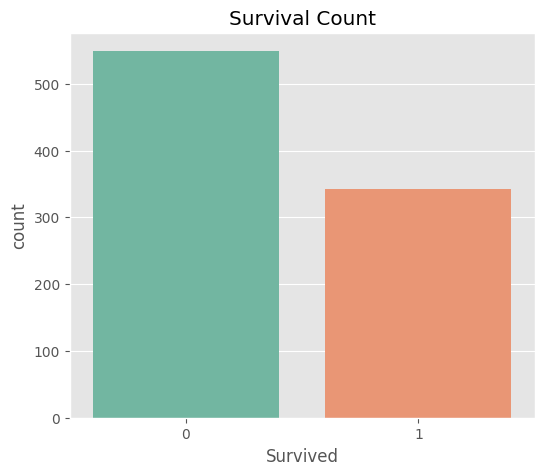

In [10]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=train,
    x="Survived",
    palette="Set2"
)

plt.title("Survival Count")
plt.show()

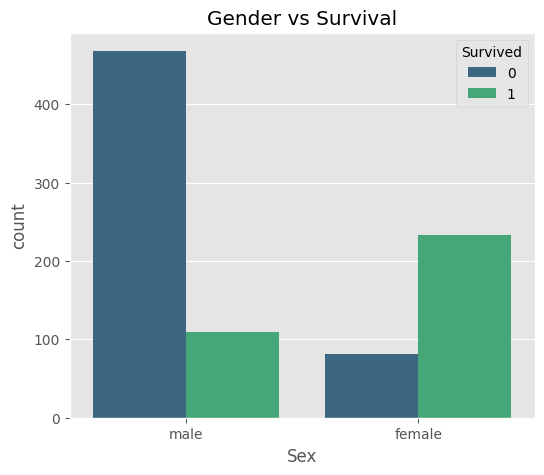

In [11]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=train,
    x="Sex",
    hue="Survived",
    palette="viridis"
)

plt.title("Gender vs Survival")
plt.show()

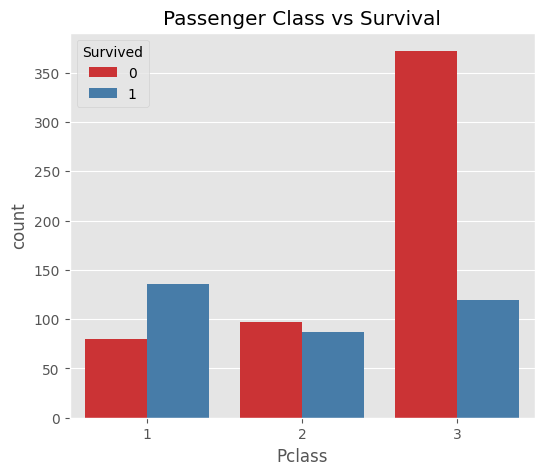

In [12]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=train,
    x="Pclass",
    hue="Survived",
    palette="Set1"
)

plt.title("Passenger Class vs Survival")
plt.show()

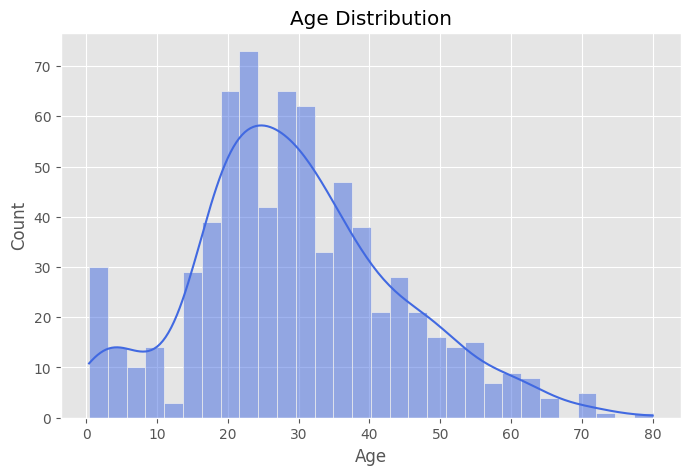

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    train["Age"],
    bins=30,
    kde=True,
    color="royalblue"
)

plt.title("Age Distribution")
plt.show()

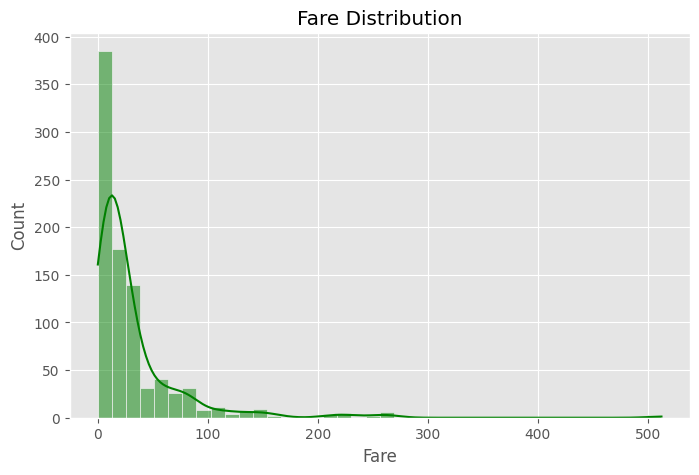

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    train["Fare"],
    bins=40,
    kde=True,
    color="green"
)

plt.title("Fare Distribution")
plt.show()

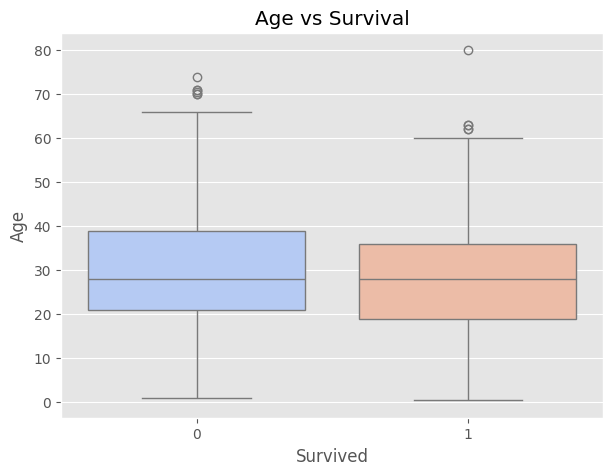

In [15]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=train,
    x="Survived",
    y="Age",
    palette="coolwarm"
)

plt.title("Age vs Survival")
plt.show()

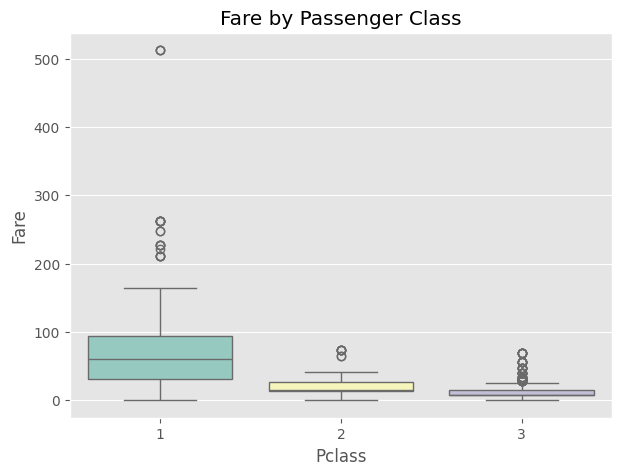

In [16]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=train,
    x="Pclass",
    y="Fare",
    palette="Set3"
)

plt.title("Fare by Passenger Class")
plt.show()

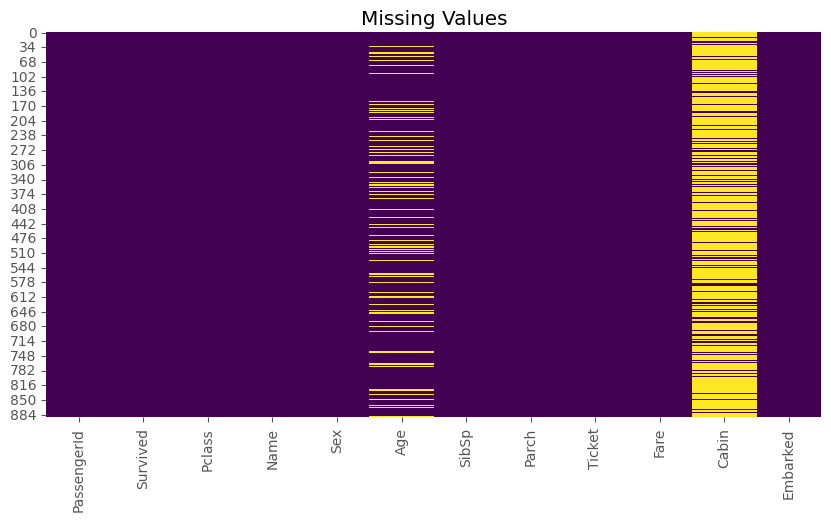

In [17]:
plt.figure(figsize=(10,5))

sns.heatmap(
    train.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values")
plt.show()

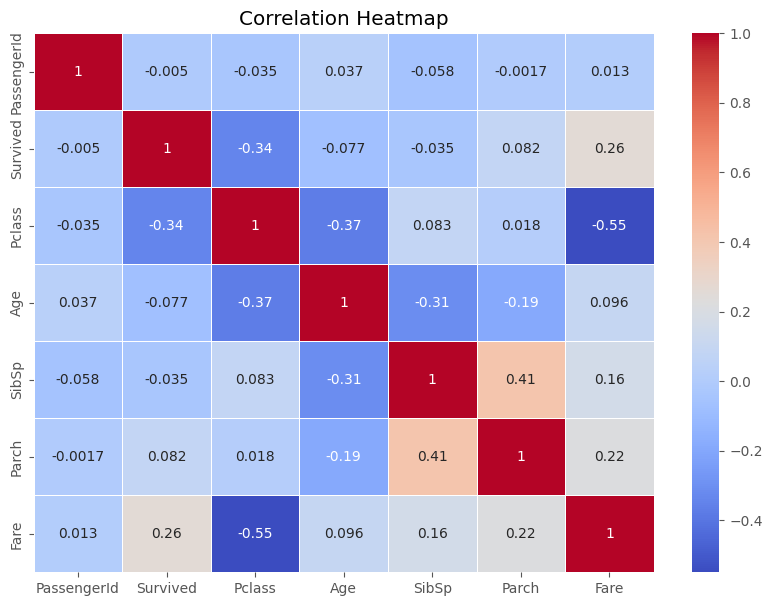

In [18]:
plt.figure(figsize=(10,7))

corr = train.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

In [19]:
train.groupby("Sex")["Survived"].mean().sort_values(ascending=False)

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

# 🧹 Data Cleaning & Feature Engineering

In this section we will:

- Handle missing values
- Create new informative features
- Encode categorical variables
- Prepare the dataset for Machine Learning

In [ ]:
test_ids = test["PassengerId"]